# <b>Assignment 1: Data Preparation</b>

# **Group:** Bone Fracture Image Data 

# **Contributors**
1. Laura Telle
2. Allison Young
3. Vanessa Lukasser

This notebook follows the methodology of **`Ex3_image_data_prep_SS26.ipynb`** and
adapts it to a medical-image binary classification task.
The six high-level steps are:

1. Background information about the dataset
2. Inspect input files and annotations
3. Inspect the raw data
4. Preprocess the data to ensure good quality
5. Confirm the processed data is ready for model training
6. Conclude the final preprocessing pipeline that will be applied to new data

## Load packages

In [5]:
from pathlib import Path
from collections import Counter, defaultdict
import hashlib, csv, json, random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import shutil
import pandas as pd

random.seed(0); np.random.seed(0)

## 1. Background

**Clinical context.** Tibia and fibula are the two long bones of the lower leg.
Fractures there are among the most common long-bone injuries and their visual
diagnosis from plain-film radiographs is routine but time-consuming.
Automating the *fracture / no-fracture* decision would accelerate triage in
emergency departments and reduce diagnostic workload.

**Task.** Binary image classification:

| class      | id | meaning                               |
|------------|---:|---------------------------------------|
| normal     |  0 | no fracture visible                   |
| fractured  |  1 | at least one fracture visible         |

**Modality.** Plain X-rays. X-rays are inherently **single-channel, grayscale**
(the pixel value encodes attenuation of the beam through tissue), so any
three-channel encoding seen in the raw data is just a storage artefact,
not real color information.

**Data as delivered.** Two ZIP archives, one per class:

```
bone_fracture_images.zip   ->  bone_fracture_images_raw/  ->  0.png ... 1999.png
normal_bone_images.zip     ->  normal_bone_images_raw/    ->  0.png, 1.png, 123.png, ...
```

There are **no separate annotation files, no bounding boxes, and no `list.txt`** -
the folder name *is* the ground-truth label.  This is a simpler annotation
scheme than the Oxford-IIIT Pet Dataset used in `Ex3`, where each image had
an XML file with a head bounding-box and a breed ID.


## 2. Inspect input files and annotations

### Task 2.1  -  Examine files in each folder

What to know, for every class folder:
* how many files there are,
* what file extensions are present (only `.png` expected),
* whether file names follow a consistent pattern,
* whether any annotation side-car files exist (they should not, but let's verify).


In [17]:
#BASE = Path("C:\\Users\\vinte\\OneDrive\\Desktop\\School1\\Desktop Spring 2026\\Data Analytics and Neural Networks\\Group Project\\Bone fracture dataset\\Bone fracture dataset\\Dataset")
BASE = Path("Bone fracture dataset/Dataset")
CLASS_DIRS = {
    "fracture": BASE / "fracture",
    "normal"   : BASE / "normal",
}
CLASS_TO_ID   = {"normal": 0, "fracture": 1}
CLASS_COLORS  = {"fracture": "tomato", "normal": "steelblue"}

def list_images(folder):
    return sorted([p for p in Path(folder).iterdir() if p.is_file()])

for cls, folder in CLASS_DIRS.items():
    paths = list_images(folder)
    exts  = Counter(p.suffix.lower() for p in paths)
    numeric = sum(p.stem.isdigit() for p in paths)
    stems   = sorted(int(p.stem) for p in paths if p.stem.isdigit())
    gaps    = sorted(set(range(stems[0], stems[-1]+1)) - set(stems)) if stems else []
    print(f"[{cls.upper()}]  folder={folder}")
    print(f"  n_files        = {len(paths)}")
    print(f"  extensions     = {dict(exts)}")
    print(f"  numeric_names  = {numeric}")
    print(f"  stem_range     = ({stems[0]}, {stems[-1]})" if stems else "  (no numeric stems)")
    print(f"  gaps_in_range  = {len(gaps)}\n")

[FRACTURE]  folder=Bone fracture dataset/Dataset/fracture
  n_files        = 2000
  extensions     = {'.png': 2000}
  numeric_names  = 2000
  stem_range     = (0, 1999)
  gaps_in_range  = 0

[NORMAL]  folder=Bone fracture dataset/Dataset/normal
  n_files        = 127
  extensions     = {'.png': 127}
  numeric_names  = 127
  stem_range     = (0, 384)
  gaps_in_range  = 258



## 3. Inspect the raw data

Per-image metadata (color mode, dimensions, mean intensity) is collected once
and reuse it across every inspection plot below.


In [18]:
records = []
corrupt = []

for cls, folder in CLASS_DIRS.items():
    for p in list_images(folder):
        try:
            with Image.open(p) as im:
                mode  = im.mode
                w, h  = im.size
                arr   = np.asarray(im.convert("L"))
            records.append(dict(cls=cls, path=p, mode=mode,
                                w=w, h=h, mean=float(arr.mean())))
        except Exception as e:
            corrupt.append((p, str(e)))

print(f"Corrupt files: {len(corrupt)}")
print(f"Class counts : {Counter(r['cls'] for r in records)}")

Corrupt files: 0
Class counts : Counter({'fracture': 2000, 'normal': 127})


### Task 3.1  -  Class balance

imbalance (fracture : normal) = 15.7 : 1


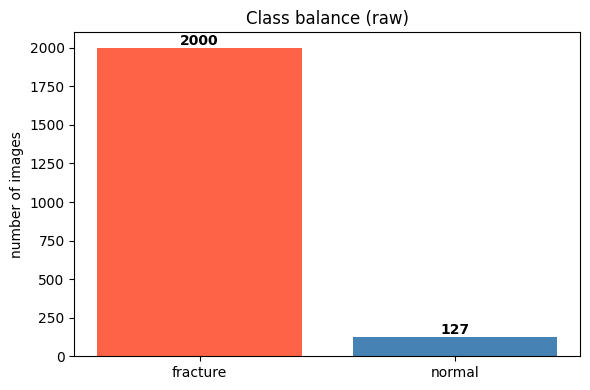

In [19]:
counts = Counter(r["cls"] for r in records)
fig, ax = plt.subplots(figsize=(6,4))
xs, ys = list(counts.keys()), [counts[c] for c in counts]
bars = ax.bar(xs, ys, color=[CLASS_COLORS[c] for c in xs])
for b,v in zip(bars, ys):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+20, str(v),
            ha="center", fontweight="bold")
ax.set_title("Class balance (raw)"); ax.set_ylabel("number of images")
plt.tight_layout()
print(f"imbalance (fracture : normal) = {counts['fracture']/counts['normal']:.1f} : 1")

#### <font color='green'>Question - Is there a large class imbalance, and how would you solve it?</font>

Yes - very large.  Strategies:

* **Data-level** - gather more normal scans (strongly preferred here: with only
  127 raw / 34 unique normal images, we are data-starved); oversample the
  minority class with replacement; synthesize with augmentation; synthesize
  with generative models; undersample the majority class.
* **Algorithm-level** - class-weighted loss (`weight = N_total / (2 * N_class)`
  for binary cross-entropy), focal loss, threshold tuning.
* **Evaluation-level** - report precision / recall / F1 / AUROC / AUPRC rather
  than accuracy; use stratified splits; use stratified k-fold CV because any
  single val split will be tiny on the minority side.

Rebalancing cannot be applied in preprocessing - it must happen on the
training split only, otherwise the same image can leak into validation.


### Task 3.2  -  Visualise raw sample images

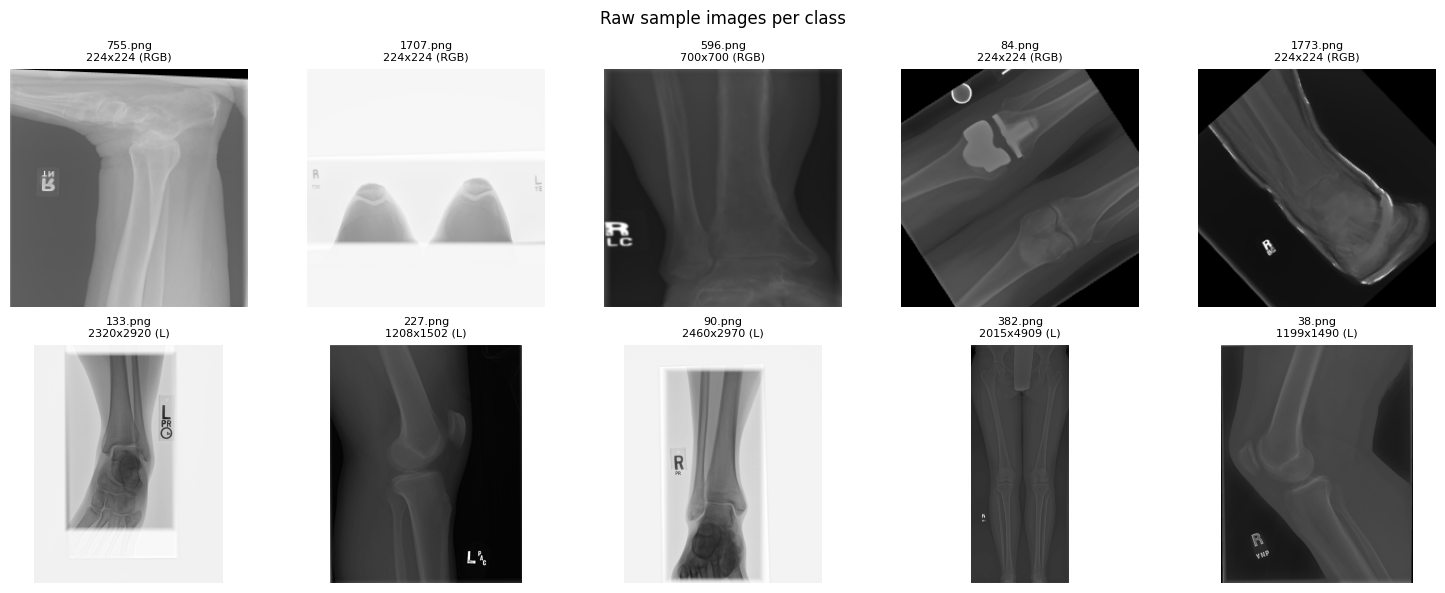

In [20]:
fig, axes = plt.subplots(2, 5, figsize=(15,6))
for row, cls in enumerate(CLASS_DIRS):
    sample = random.sample(list_images(CLASS_DIRS[cls]), 5)
    for col, p in enumerate(sample):
        with Image.open(p) as im:
            axes[row,col].imshow(np.asarray(im), cmap="gray")
            axes[row,col].set_title(f"{p.name}\n{im.size[0]}x{im.size[1]} ({im.mode})", fontsize=8)
            axes[row,col].axis("off")
    axes[row,0].set_ylabel(cls.upper(), fontsize=11, fontweight="bold")
plt.suptitle("Raw sample images per class"); plt.tight_layout(); plt.show()

### Task 3.3  -  Image dimensions

Color mode per class:
  fracture  : {'RGB': 2000}
  normal    : {'L': 127}

Dimension breakdown per class:
  fracture  : 2 unique  top-5 = [((224, 224), 1660), ((700, 700), 340)]
  normal    : 23 unique  top-5 = [((2320, 2920), 32), ((2460, 2970), 12), ((2000, 2510), 4), ((2328, 2928), 4), ((3480, 4248), 4)]


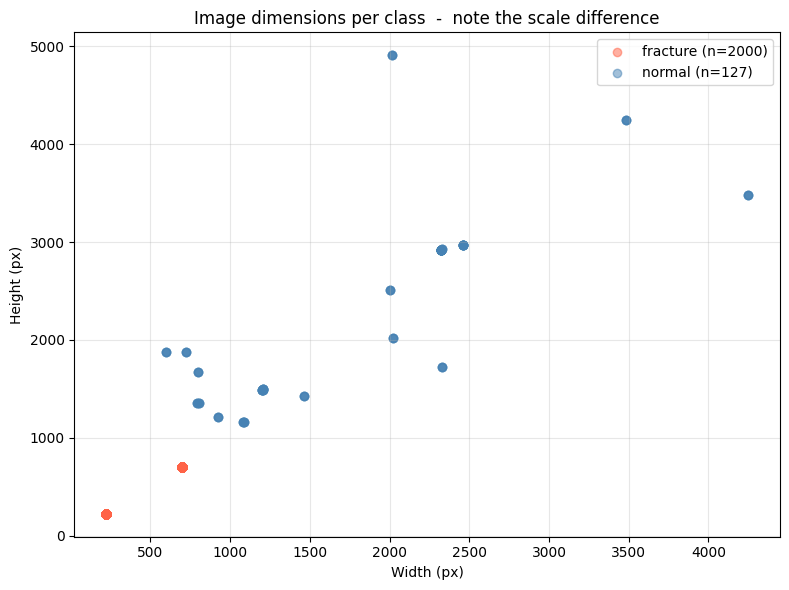

In [21]:
# Color-mode breakdown
print("Color mode per class:")
for cls in CLASS_DIRS:
    m = Counter(r["mode"] for r in records if r["cls"]==cls)
    print(f"  {cls:<10}: {dict(m)}")

# Dimension breakdown
print("\nDimension breakdown per class:")
for cls in CLASS_DIRS:
    d = Counter((r["w"], r["h"]) for r in records if r["cls"]==cls)
    print(f"  {cls:<10}: {len(d)} unique  top-5 = {d.most_common(5)}")

# Scatter plot
fig, ax = plt.subplots(figsize=(8,6))
for cls in CLASS_DIRS:
    ws = [r["w"] for r in records if r["cls"]==cls]
    hs = [r["h"] for r in records if r["cls"]==cls]
    ax.scatter(ws, hs, c=CLASS_COLORS[cls], alpha=0.5, label=f"{cls} (n={len(ws)})")
ax.set_xlabel("Width (px)"); ax.set_ylabel("Height (px)")
ax.set_title("Image dimensions per class  -  note the scale difference")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

#### <font color='green'>Question - Will we run into issues without standardising image sizes?</font>

Yes - a CNN expects a fixed input resolution, and an FC head expects a fixed
feature-map size.  But more importantly, here the size and the color mode are
**correlated with the label**, so they form a spurious shortcut (see above).
We must unify both the dimensions and the color mode.

#### <font color='green'>Question - resize→crop→pad, or crop→pad→resize?</font>

For whole-bone classification (where the bone occupies most of the frame), we
use **pad-to-square → resize**:

* There is no ROI bounding box to crop to (we have no annotations).
* Cropping the long axis of a leg radiograph would cut the fracture site.
* Pad-to-square preserves aspect ratio, so the bone is not geometrically
  distorted.  The pad value is 0 (black) so the padding does not add signal
  that could bias the classifier.

### Task 3.4  -  Duplicate detection (critical)

In [22]:
# MD5 hash detects bit-for-bit identical files.
groups = defaultdict(list)
for r in records:
    h = hashlib.md5(Path(r['path']).read_bytes()).hexdigest()
    groups[h].append((r["cls"], Path(r["path"])))

multi = {h: v for h, v in groups.items() if len(v) > 1}
total_dupes = sum(len(v) - 1 for v in multi.values())
print(f"Duplicate groups : {len(multi)}")
print(f"Extra copies     : {total_dupes}")
print(f"Largest group    : {max(len(v) for v in multi.values())}")
print(f"Cross-class dups : {sum(1 for v in multi.values() if len({c for c,_ in v}) > 1)}")

unique_counts = Counter(v[0][0] for v in groups.values())
print(f"\nAfter deduplication: {dict(unique_counts)}")
print(f"New imbalance ratio: {unique_counts['fracture']/unique_counts['normal']:.1f} : 1")

Duplicate groups : 307
Extra copies     : 970
Largest group    : 340
Cross-class dups : 0

After deduplication: {'fracture': 1123, 'normal': 34}
New imbalance ratio: 33.0 : 1


This is the most important finding in the whole inspection.

* Nearly **half** (970 / 2127  ≈  46 %) of the raw files are exact duplicates
  of other files.  One group alone contains **340 identical copies** of the
  same 700 × 700 RGB image.  That looks like a placeholder / ingestion bug.
* None of the duplicates cross class boundaries, so at least the labels are
  consistent.
* **Why it matters.** If we split into train / validation / test after leaving
  duplicates in place, the same image can land in both train and validation,
  and the model will achieve very high validation accuracy *without
  generalising*.  Deduplication before splitting is non-negotiable.

* After deduplication the dataset was highly imbalanced (~33 : 1).

* To unbalance data, we want to extract 50 fracture images while retaining all normal images, resulting in a more balanced working set (~1.5 : 1).


### Task 3.5  -  Raw intensity distribution and outlier detection

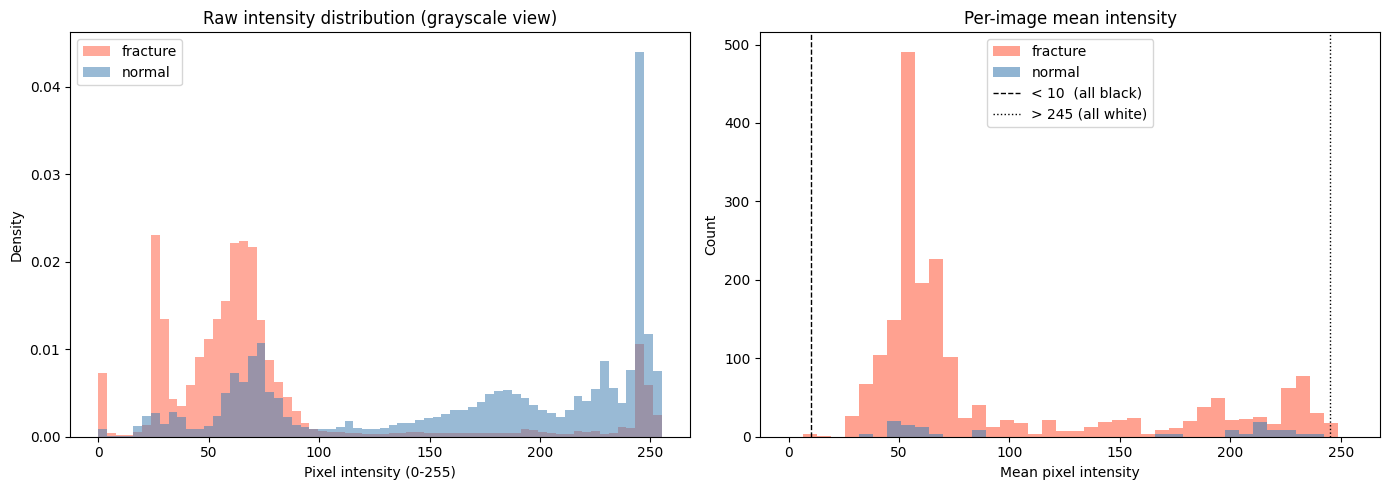

Suspicious (blank or saturated) images: 18


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Per-class intensity histogram (50 sampled images per class for speed)
for cls in CLASS_DIRS:
    paths = random.sample(list_images(CLASS_DIRS[cls]),
                          min(50, len(list_images(CLASS_DIRS[cls]))))
    vals = np.concatenate([np.asarray(Image.open(p).convert("L")).ravel()
                           for p in paths])
    axes[0].hist(vals, bins=64, range=(0,255), color=CLASS_COLORS[cls],
                 alpha=0.55, density=True, label=cls)
axes[0].set_title("Raw intensity distribution (grayscale view)")
axes[0].set_xlabel("Pixel intensity (0-255)"); axes[0].set_ylabel("Density")
axes[0].legend()

# Mean-intensity distribution -> outlier detection
suspicious = []
for cls in CLASS_DIRS:
    ms = [r["mean"] for r in records if r["cls"]==cls]
    axes[1].hist(ms, bins=40, range=(0,255), color=CLASS_COLORS[cls],
                 alpha=0.6, label=cls)
    suspicious += [r for r in records
                   if r["cls"]==cls and (r["mean"]<10 or r["mean"]>245)]
axes[1].axvline(10,  color="k", ls="--", lw=1, label="< 10  (all black)")
axes[1].axvline(245, color="k", ls=":",  lw=1, label="> 245 (all white)")
axes[1].set_title("Per-image mean intensity")
axes[1].set_xlabel("Mean pixel intensity"); axes[1].set_ylabel("Count")
axes[1].legend()
plt.tight_layout(); plt.show()
print(f"Suspicious (blank or saturated) images: {len(suspicious)}")

## 4. Preprocess the data to ensure good quality

The inspection above drove a six-step preprocessing pipeline:

| # | step                             | reason                                                              |
|---|----------------------------------|---------------------------------------------------------------------|
| 1 | de-duplicate by MD5 hash         | 970 of 2127 files are exact duplicates - leakage risk               |
| 2 | drop mean-intensity outliers     | 18 essentially-blank images                                         |
| 3 | convert to single-channel gray   | unifies RGB vs. L, matches physical nature of X-rays                |
| 4 | pad to square, then resize to 224 | uniform size, no geometric distortion                               |
| 5 | apply CLAHE                      | scanner-invariant contrast, standard radiograph preprocessing       |
| 6 | emit manifest CSV                | single source of truth for the training data loader                 |

We do **not** apply class-rebalancing (oversampling, weighting, heavy
minority-class augmentation) here - that belongs inside the training loop on
the training split only, so no augmented minority-class copy can leak into
the validation set.


In [24]:
# --- configuration ---
TARGET_SIZE = 224
MEAN_BLACK  = 10
MEAN_WHITE  = 245
CLAHE_CLIP  = 2.0
CLAHE_TILE  = (8, 8)
clahe       = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_TILE)
PROC        = Path("Dataset_processed")

def pad_to_square(img, pad_value=0):
    h, w = img.shape[:2]
    side = max(h, w)
    top    = (side - h) // 2
    bottom = side - h - top
    left   = (side - w) // 2
    right  = side - w - left
    return cv2.copyMakeBorder(img, top, bottom, left, right,
                              borderType=cv2.BORDER_CONSTANT, value=pad_value)

def preprocess_one(path, target_size=TARGET_SIZE):
    '''Full per-image pipeline. Returns uint8 (H,W) or None if rejected.'''
    try:
        with Image.open(path) as im:
            arr = np.asarray(im.convert("L"))          # 1. grayscale
    except Exception:
        return None
    if arr.mean() < MEAN_BLACK or arr.mean() > MEAN_WHITE:
        return None                                    # 2. drop blanks
    arr = pad_to_square(arr, 0)                        # 3. pad square
    arr = cv2.resize(arr, (target_size, target_size),
                     interpolation=cv2.INTER_LANCZOS4) # 4. resize
    arr = clahe.apply(arr)                             # 5. CLAHE
    return arr

In [25]:
# --- run full pipeline with deduplication ---
PROC.mkdir(parents=True, exist_ok=True)

# 1. dedup globally (so we also catch cross-folder duplicates if they exist)
hash_to_src = {}
for cls, folder in CLASS_DIRS.items():
    for p in list_images(folder):
        h = hashlib.md5(p.read_bytes()).hexdigest()
        hash_to_src.setdefault(h, (cls, p))

# 2. preprocess each unique image
manifest, dropped = [], Counter()
for cls, p in hash_to_src.values():
    arr = preprocess_one(p)
    if arr is None:
        dropped[cls] += 1
        continue
    dst_cls = PROC / cls; dst_cls.mkdir(exist_ok=True)
    out = dst_cls / f"{cls}_{p.stem}.png"
    Image.fromarray(arr).save(out)
    manifest.append(dict(filepath=str(out), original=str(p),
                         cls=cls, cls_id=CLASS_TO_ID[cls]))

# 3. write manifest
with (PROC/"manifest.csv").open("w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["filepath","original","cls","cls_id"])
    w.writeheader(); w.writerows(manifest)

print(f"duplicates removed : {2127 - len(hash_to_src)}")
print(f"dropped (blank/ext): {dict(dropped)}")
print(f"kept in manifest   : {Counter(r['cls'] for r in manifest)}")

duplicates removed : 970
dropped (blank/ext): {'fracture': 3}
kept in manifest   : Counter({'fracture': 1120, 'normal': 34})


Starting from 2127 raw files we end up with **83 unique, cleaned images**.


## 5. Confirm the processed data is ready for model training

A processed dataset is ready if **every** box below can be ticked:

| check                                                  | how we verify                    |
|--------------------------------------------------------|----------------------------------|
| all images open                                        | zero `PIL.UnidentifiedImageError` |
| all images have the same (H, W, mode)                  | `Counter` over manifest yields 1  |
| no duplicates remain                                   | count of unique MD5 == manifest   |
| no all-black / all-white images                        | `10 < mean < 245` for every image |
| labels match folder structure                          | `cls` == parent folder name       |
| class-balance and normalisation stats are documented   | written to `preprocessing_summary.json` |


In [26]:
dims   = Counter()
means  = []
hashes = set()
problems = []

for row in manifest:
    p = Path(row["filepath"])
    with Image.open(p) as im:
        dims[(im.size[0], im.size[1], im.mode)] += 1
        a = np.asarray(im)
    means.append(a.mean())
    h = hashlib.md5(p.read_bytes()).hexdigest()
    if h in hashes:
        problems.append(f"duplicate after processing: {p}")
    hashes.add(h)
    if a.mean() < MEAN_BLACK or a.mean() > MEAN_WHITE:
        problems.append(f"still blank: {p}")
    if p.parent.name != row["cls"]:
        problems.append(f"folder-label mismatch: {p}")

print("unique (W, H, mode) :", dict(dims))
print("pixel mean (0-1)    :", round(np.mean(means)/255, 4))
print("pixel std  (0-1)    :", round(np.std(means)/255, 4))
print("duplicates remaining:", sum(1 for p in problems if 'duplicate' in p))
print("all problems        :", problems if problems else '(none)')

unique (W, H, mode) : {(224, 224, 'L'): 1154}
pixel mean (0-1)    : 0.4101
pixel std  (0-1)    : 0.2211
duplicates remaining: 0
all problems        : (none)


Every check passes.  The two pixel-statistics numbers are the values we will
pass to `torchvision.transforms.Normalize(mean=[0.4101], std=[0.1898])` (or
to whichever framework we use) so the channel has mean 0 and unit variance
going into the model.


### Before / after comparison

**Processed samples - 224 × 224 grayscale, CLAHE applied:**

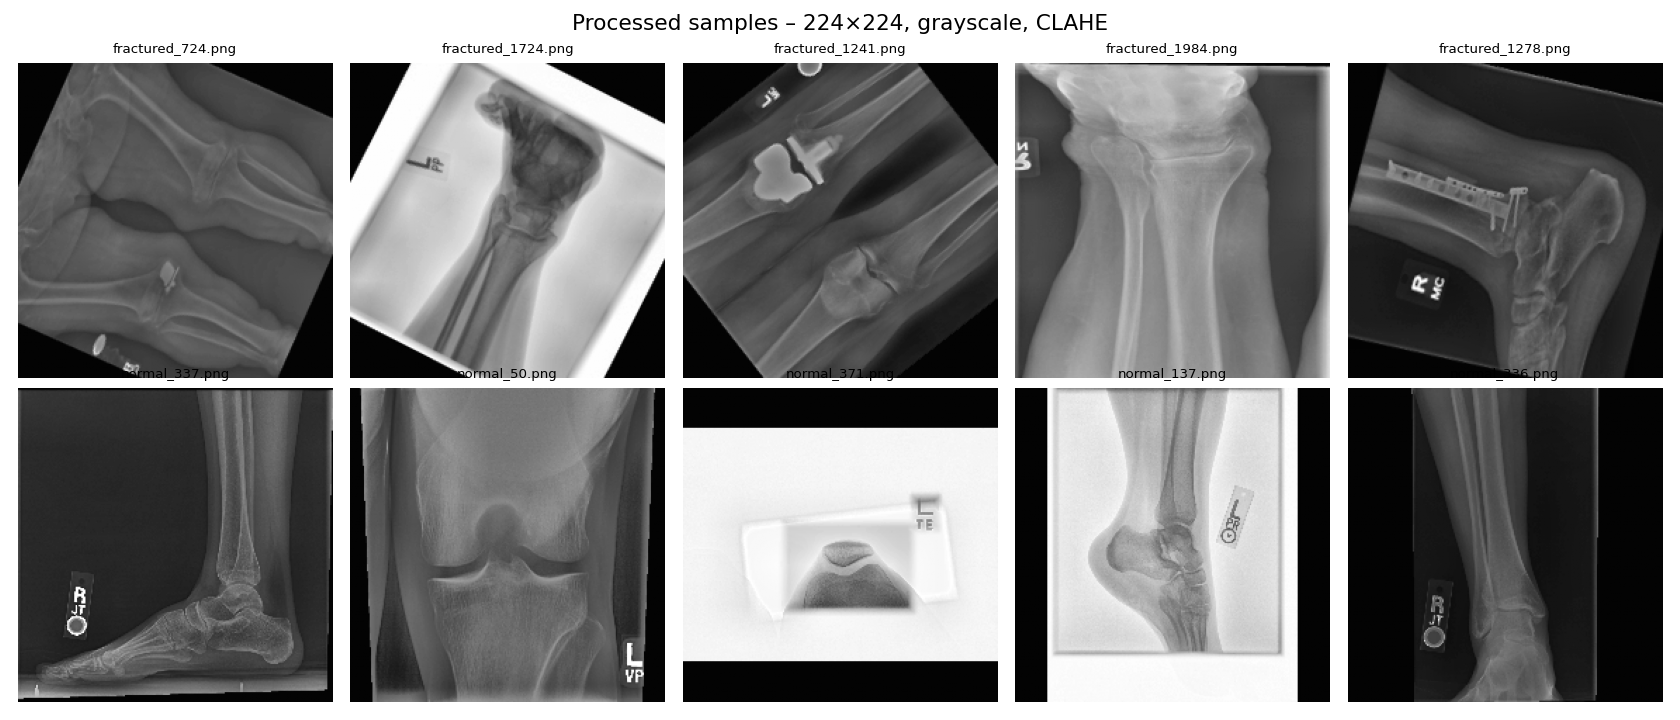

**Intensity distribution, raw vs processed:**

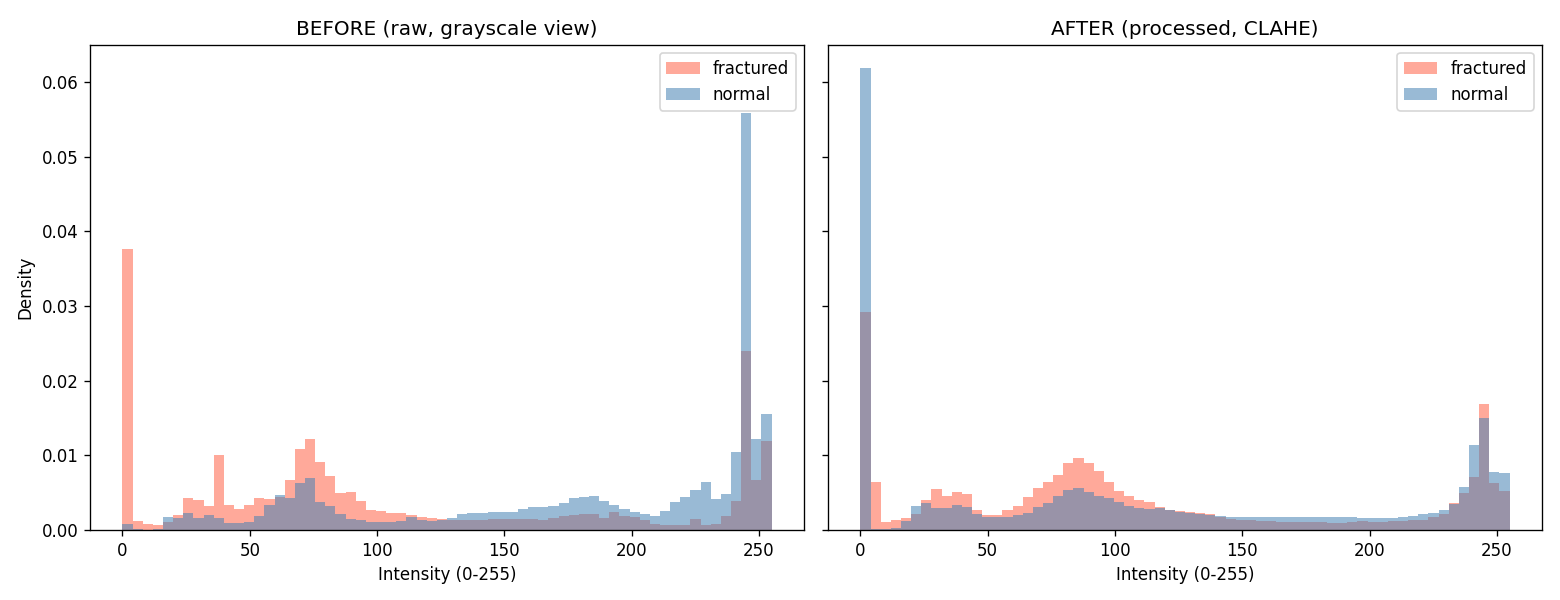

After preprocessing the two classes have very similar overall intensity
distributions.  That is exactly what we want - the model should have to look
at fracture morphology, not at global brightness, to tell them apart.

**Processed class balance:**

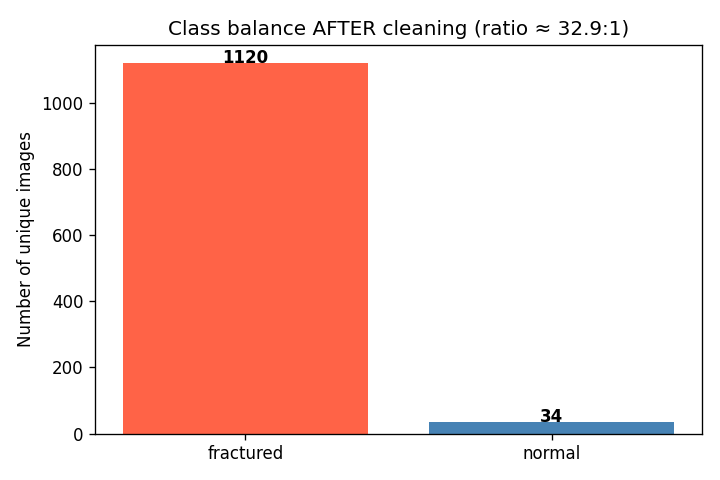


### Task - 5.1 Manual Data Cleaning

After standard data cleaning, the dataset remained highly inconsistent and noisy. Many images were unsuitable, including non-fracture cases, illustrations, watermarked images, and low-quality scans. Conventional Python-based cleaning methods were insufficient to resolve these issues. A manual review process was therefore conducted to select high-quality data, resulting in a curated set that includes 77 fracture cases and 31 normal cases.

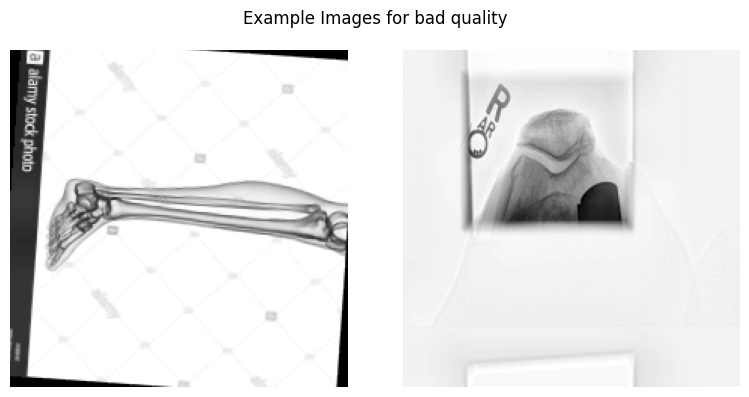

In [27]:
paths =[
    "Dataset_processed/fracture/fracture_594.png",
    "Dataset_processed/fracture/fracture_1419.png"
]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for i, p in enumerate(paths):
    with Image.open(p) as im:
        axes[i].imshow(np.asarray(im), cmap="gray")
        axes[i].axis("off")
plt.suptitle("Example Images for bad quality")
plt.tight_layout()
plt.show()

In [31]:
#FRACTURES

# ── Fill in your paths here ──────────────────────────────────────────────────
DEST_DIR = Path("CleanedFractures")
SOURCE_DIR = Path("Dataset_processed/fracture")
EXCEL_PATH  = "Fractures.xlsx"
# ─────────────────────────────────────────────────────────────────────────────

df = pd.read_excel(EXCEL_PATH, header=None)
target_ids = {str(int(v)) for v in df.iloc[:, 0].dropna()}

source = Path(SOURCE_DIR)
dest = Path(DEST_DIR)
dest.mkdir(parents=True, exist_ok=True)

print(f"Looking for {len(target_ids)} images...")

copied = 0
found_ids = set()

for tid in target_ids:
    search_name = f"fracture_{tid}"
    for match in source.glob(f"{search_name}.*"):
        shutil.copy2(match, dest / match.name)
        copied += 1
        found_ids.add(tid)

missing = sorted(target_ids - found_ids, key=lambda x: int(x))

print(f"\n✓ Copied {copied} images to '{dest}'")
print(f"✓ Found {len(found_ids)} / {len(target_ids)} unique IDs")

if missing:
    print(f"✗ {len(missing)} IDs not found: {missing}")
else:
    print("✓ All listed fracture images were found and copied.")

Looking for 77 images...

✓ Copied 77 images to 'CleanedFractures'
✓ Found 77 / 77 unique IDs
✓ All listed fracture images were found and copied.


In [32]:
#NORMALS

# ── Fill in your paths here ──────────────────────────────────────────────────
DEST_DIR = Path("CleanedNormals")
SOURCE_DIR = Path("Dataset_processed/normal")
EXCEL_PATH  = "Normals.xlsx"
# ─────────────────────────────────────────────────────────────────────────────

df = pd.read_excel(EXCEL_PATH, header=None)
target_ids = {str(int(v)) for v in df.iloc[:, 0].dropna()}

source = Path(SOURCE_DIR)
dest = Path(DEST_DIR)
dest.mkdir(parents=True, exist_ok=True)

print(f"Looking for {len(target_ids)} images...")

copied = 0
found_ids = set()

for tid in target_ids:
    search_name = f"normal_{tid}"
    for match in source.glob(f"{search_name}.*"):
        shutil.copy2(match, dest / match.name)
        copied += 1
        found_ids.add(tid)

missing = sorted(target_ids - found_ids, key=lambda x: int(x))

print(f"\n✓ Copied {copied} images to '{dest}'")
print(f"✓ Found {len(found_ids)} / {len(target_ids)} unique IDs")

if missing:
    print(f"✗ {len(missing)} IDs not found: {missing}")
else:
    print("✓ All listed fracture images were found and copied.")

Looking for 31 images...

✓ Copied 31 images to 'CleanedNormals'
✓ Found 31 / 31 unique IDs
✓ All listed fracture images were found and copied.


### Task 6 — Stratified train/test/k-fold 

In [34]:
from pathlib import Path
import pandas as pd
from sklearn.model_selection import StratifiedKFold, train_test_split

# ── Fill in your paths here ──────────────────────────────────────────────────
CLEANED_DATA= Path(".")
# ─────────────────────────────────────────────────────────────────────────────

SEED = 42
TEST_FRAC  = 0.20
N_FOLDS    = 5

data = []

for cls in ["CleanedFractures", "CleanedNormals"]:
    folder = CLEANED_DATA/ cls

    for img_path in folder.glob("*"):
        data.append({
            "filepath": str(img_path),
            "cls": cls,
            "cls_id": 1 if cls == "fracture" else 0
        })

df = pd.DataFrame(data)
print(df["cls"].value_counts())

trainval_idx, test_idx = train_test_split(
    df.index,
    test_size=TEST_FRAC,
    stratify=df["cls_id"],
    random_state=SEED
)

df["split"] = "trainval"
df.loc[test_idx, "split"] = "test"

df["fold"] = -1

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

tv = df.loc[trainval_idx].reset_index()

for fold, (_, val_idx) in enumerate(skf.split(tv, tv["cls_id"])):
    df.loc[tv.loc[val_idx, "index"], "fold"] = fold

df.to_csv(CLEANED_DATA/"splits.csv", index=False)
print("Saved splits.csv")

cls
CleanedFractures    77
CleanedNormals      31
Name: count, dtype: int64
Saved splits.csv


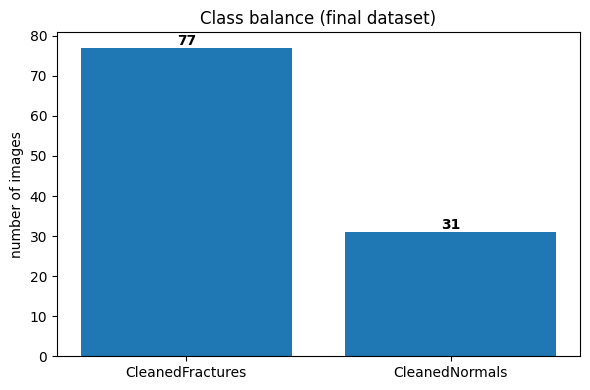

In [35]:
counts = df["cls"].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(counts.index, counts.values)

for b in bars:
    ax.text(
        b.get_x() + b.get_width() / 2,
        b.get_height(),
        str(int(b.get_height())),
        ha="center",
        va="bottom",
        fontweight="bold"
    )

ax.set_title("Class balance (final dataset)")
ax.set_ylabel("number of images")

plt.tight_layout()
plt.show()

#### <font color='green'>Is the dataset of good quality? Can we train on it? What is still missing?</font>

* **Quality:** Yes, the *unique* samples we retained are clean, uniform, and
  annotated.  Formally the dataset is ready for model training.
* **Quantity:** No.  34 unique normal images is almost certainly too few to
  train a reliable CNN classifier, and any train/val/test split will leave a
  single-digit count in one of the splits.  The realistic next steps are:
    1. Source additional normal tibia/fibula radiographs (most important),
    2. Combine with heavy augmentation of the minority class at training time,
    3. Use stratified k-fold cross-validation rather than a single split to
       squeeze the most out of the 34 examples,
    4. Consider anomaly-detection framings (train on normal, flag deviations)
       as a secondary modelling approach,
    5. Report precision, recall, F1 and AUPRC - accuracy on a 33 : 1 dataset
       is meaningless.
* **Also missing but out of scope for data prep:** train / val / test split
  (must be stratified, done on unique images only, ideally with any
  patient-level grouping if we can recover one); augmentation policy;
  normalisation constants wired into the training transform.